In [ ]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

NLP From Scratch: Translation with a Sequence to Sequence Network and Attention
===============================================================================

**Author**: [Sean Robertson](https://github.com/spro)

This tutorials is part of a three-part series:

-   [NLP From Scratch: Classifying Names with a Character-Level
    RNN](https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html)
-   [NLP From Scratch: Generating Names with a Character-Level
    RNN](https://pytorch.org/tutorials/intermediate/char_rnn_generation_tutorial.html)
-   [NLP From Scratch: Translation with a Sequence to Sequence Network
    and
    Attention](https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html)

This is the third and final tutorial on doing **NLP From Scratch**,
where we write our own classes and functions to preprocess the data to
do our NLP modeling tasks.

In this project we will be teaching a neural network to translate from
French to English.

``` {.sh}
[KEY: > input, = target, < output]

> il est en train de peindre un tableau .
= he is painting a picture .
< he is painting a picture .

> pourquoi ne pas essayer ce vin delicieux ?
= why not try that delicious wine ?
< why not try that delicious wine ?

> elle n est pas poete mais romanciere .
= she is not a poet but a novelist .
< she not not a poet but a novelist .

> vous etes trop maigre .
= you re too skinny .
< you re all alone .
```

\... to varying degrees of success.

This is made possible by the simple but powerful idea of the [sequence
to sequence network](https://arxiv.org/abs/1409.3215), in which two
recurrent neural networks work together to transform one sequence to
another. An encoder network condenses an input sequence into a vector,
and a decoder network unfolds that vector into a new sequence.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/seq2seq.png)

To improve upon this model we\'ll use an [attention
mechanism](https://arxiv.org/abs/1409.0473), which lets the decoder
learn to focus over a specific range of the input sequence.

**Recommended Reading:**

I assume you have at least installed PyTorch, know Python, and
understand Tensors:

-   <https://pytorch.org/> For installation instructions
-   `/beginner/deep_learning_60min_blitz`{.interpreted-text role="doc"}
    to get started with PyTorch in general
-   `/beginner/pytorch_with_examples`{.interpreted-text role="doc"} for
    a wide and deep overview
-   `/beginner/former_torchies_tutorial`{.interpreted-text role="doc"}
    if you are former Lua Torch user

It would also be useful to know about Sequence to Sequence networks and
how they work:

-   [Learning Phrase Representations using RNN Encoder-Decoder for
    Statistical Machine Translation](https://arxiv.org/abs/1406.1078)
-   [Sequence to Sequence Learning with Neural
    Networks](https://arxiv.org/abs/1409.3215)
-   [Neural Machine Translation by Jointly Learning to Align and
    Translate](https://arxiv.org/abs/1409.0473)
-   [A Neural Conversational Model](https://arxiv.org/abs/1506.05869)

You will also find the previous tutorials on
`/intermediate/char_rnn_classification_tutorial`{.interpreted-text
role="doc"} and
`/intermediate/char_rnn_generation_tutorial`{.interpreted-text
role="doc"} helpful as those concepts are very similar to the Encoder
and Decoder models, respectively.

**Requirements**


In [1]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re #Regular Expression 라이브러리: 특수문자 제거, 문자 패턴 찾기 등 제
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [2]:
import os
import zipfile
from google.colab import files

# 1. 기존에 같은 폴더가 있다면 정리 (충돌 방지)
if os.path.exists('names'):
    import shutil
    shutil.rmtree('names')
    print("기존 폴더를 삭제했습니다.")

# 2. 파일 업로드 버튼 생성
print("아래 [파일 선택] 버튼을 눌러 컴퓨터에 있는 'names.zip' 파일을 업로드하세요.")
uploaded = files.upload()

# 3. 업로드된 zip 파일 압축 풀기
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"'{filename}' 압축을 해제합니다...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.') # 현재 위치(/content/)에 압축 해제
        print("완료!")
    else:
        print("zip 파일이 아닙니다.")

# 4. 잘 들어왔는지 확인
print("\n[파일 목록 확인]")
if os.path.exists('data/names'):
    print(f"names 폴더 내 파일 개수: {len(os.listdir('data/names'))}")
    print(os.listdir('data/names')[:]) # 파일 5개만 예시로 출력
else:
    print("names 폴더가 보이지 않습니다. 압축 파일 구조를 확인해주세요.")

아래 [파일 선택] 버튼을 눌러 컴퓨터에 있는 'names.zip' 파일을 업로드하세요.


Saving data.zip to data.zip
'data.zip' 압축을 해제합니다...
완료!

[파일 목록 확인]
names 폴더 내 파일 개수: 18
['Japanese.txt', 'Polish.txt', 'Vietnamese.txt', 'English.txt', 'Irish.txt', 'Arabic.txt', 'Italian.txt', 'Korean.txt', 'German.txt', 'Spanish.txt', 'Greek.txt', 'Dutch.txt', 'Chinese.txt', 'Scottish.txt', 'Russian.txt', 'Portuguese.txt', 'French.txt', 'Czech.txt']


Loading data files
==================

The data for this project is a set of many thousands of English to
French translation pairs.

[This question on Open Data Stack
Exchange](https://opendata.stackexchange.com/questions/3888/dataset-of-sentences-translated-into-many-languages)
pointed me to the open translation site <https://tatoeba.org/> which has
downloads available at <https://tatoeba.org/eng/downloads> - and better
yet, someone did the extra work of splitting language pairs into
individual text files here: <https://www.manythings.org/anki/>

The English to French pairs are too big to include in the repository, so
download to `data/eng-fra.txt` before continuing. The file is a tab
separated list of translation pairs:

``` {.sh}
I am cold.    J'ai froid.
```

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>Download the data from<a href="https://download.pytorch.org/tutorial/data.zip">here</a>and extract it to the current directory.</p>

</div>



Similar to the character encoding used in the character-level RNN
tutorials, we will be representing each word in a language as a one-hot
vector, or giant vector of zeros except for a single one (at the index
of the word). Compared to the dozens of characters that might exist in a
language, there are many many more words, so the encoding vector is much
larger. We will however cheat a bit and trim the data to only use a few
thousand words per language.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/word-encoding.png)


We\'ll need a unique index per word to use as the inputs and targets of
the networks later. To keep track of all this we will use a helper class
called `Lang` which has word → index (`word2index`) and index → word
(`index2word`) dictionaries, as well as a count of each word
`word2count` which will be used to replace rare words later.


In [3]:
SOS_token = 0 #Start of Sentence
EOS_token = 1 #End of Sentence

class Lang: #word->index, index->word, word count(등장횟수) 3가지 정의 / word를 one-hot vector로 만듦
    def __init__(self, name):
        self.name = name
        self.word2index = {} #word2index = {"are":3(index),...}
        self.word2count = {} #word2count = {"are":13(count),...}
        self.index2word = {0: "SOS", 1: "EOS"} #index2word = {3(index):"are",...}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

The files are all in Unicode, to simplify we will turn Unicode
characters to ASCII, make everything lowercase, and trim most
punctuation.


In [4]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s): #유니코드 -> 아스키코드 변환
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s) # re.sub(찾을내용, 바꿀내용, 대상): ['.' ',' '!']찾아서 (.,!)그룹화-> /1(해당그룹) 앞에 '(공백)' 추가
    #"Hello!" -> "Hello !"로 변환하여 띄어쓰기 단위로 tokenizer하기 위함
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)#^(not)a~Z,!,?인 경우 공백으로 변환
    return s.strip() #normalize한 문자열 s(소문자, 아스키코드, 알파벳(+!,?)) 출력

To read the data file we will split the file into lines, and then split
lines into pairs. The files are all English → Other Language, so if we
want to translate from Other Language → English I added the `reverse`
flag to reverse the pairs.


In [5]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # Read the file and split into lines
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n') #한줄씩 리스트 형성: ['hello 안녕', 'bye 잘가',...]

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines] #pair에 대해 각각 normalize -> pairs = [['hello', '안녕],['bye','잘가'],..,]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs #Lang('eng'), Lang('fra'), [['hello', '안녕],['bye','잘가'],..,] 반환

Since there are a *lot* of example sentences and we want to train
something quickly, we\'ll trim the data set to only relatively short and
simple sentences. Here the maximum length is 10 words (that includes
ending punctuation) and we\'re filtering to sentences that translate to
the form \"I am\" or \"He is\" etc. (accounting for apostrophes replaced
earlier).


In [6]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):#fra[=0], eng 문장이 10단어 미만 and eng 문장이 eng_prefixes 튜플 내용 중 하나로 시작하면->True
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs): #위 함수 조건 충족되는 pair만 pairs로 남김
    return [pair for pair in pairs if filterPair(pair)]

The full process for preparing the data is:

-   Read text file and split into lines, split lines into pairs
-   Normalize text, filter by length and content
-   Make word lists from sentences in pairs


In [7]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse) #Lang('fra'), Lang('eng'), [['hello', '안녕],['bye','잘가'],..,]반환
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True) #preprocessing한 데이터 반환
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['elles sont jeunes et en bonne sante', 'they re young and healthy']


The Seq2Seq Model
=================

A Recurrent Neural Network, or RNN, is a network that operates on a
sequence and uses its own output as input for subsequent steps.

A [Sequence to Sequence network](https://arxiv.org/abs/1409.3215), or
seq2seq network, or [Encoder Decoder
network](https://arxiv.org/pdf/1406.1078v3.pdf), is a model consisting
of two RNNs called the encoder and decoder. The encoder reads an input
sequence and outputs a single vector, and the decoder reads that vector
to produce an output sequence.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/seq2seq.png)

Unlike sequence prediction with a single RNN, where every input
corresponds to an output, the seq2seq model frees us from sequence
length and order, which makes it ideal for translation between two
languages.

Consider the sentence `Je ne suis pas le chat noir` →
`I am not the black cat`. Most of the words in the input sentence have a
direct translation in the output sentence, but are in slightly different
orders, e.g. `chat noir` and `black cat`. Because of the `ne/pas`
construction there is also one more word in the input sentence. It would
be difficult to produce a correct translation directly from the sequence
of input words.

With a seq2seq model the encoder creates a single vector which, in the
ideal case, encodes the \"meaning\" of the input sequence into a single
vector --- a single point in some N dimensional space of sentences.


The Encoder
===========

The encoder of a seq2seq network is a RNN that outputs some value for
every word from the input sentence. For every input word the encoder
outputs a vector and a hidden state, and uses the hidden state for the
next input word.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/encoder-network.png)


In [8]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size) #Linear transformation Embedding
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True) #GRU(Gated: Reccurent Unit):이론 공부 필요함(LSTM)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input)) #embedding+dropout
        output, hidden = self.gru(embedded)
        return output, hidden

The Decoder
===========

The decoder is another RNN that takes the encoder output vector(s) and
outputs a sequence of words to create the translation.


Simple Decoder
==============

In the simplest seq2seq decoder we use only last output of the encoder.
This last output is sometimes called the *context vector* as it encodes
context from the entire sequence. This context vector is used as the
initial hidden state of the decoder.

At every step of decoding, the decoder is given an input token and
hidden state. The initial input token is the start-of-string `<SOS>`
token, and the first hidden state is the context vector (the encoder\'s
last hidden state).

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/decoder-network.png)


In [9]:
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None): #target tensor: supervised leaning
        batch_size = encoder_outputs.size(0) #동시 처리 문장 수
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token) #처음은 SOS토큰 채우기, 2D tensor[batch size, 1]
        decoder_hidden = encoder_hidden #hidden state를 encoder의 마지막 hidden state로 초기화
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden) #iteration 1회 수행
            decoder_outputs.append(decoder_output)

            if target_tensor is not None: #superviesed learning
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) #decoder output 무관하게 traget_tensor(전체batch, i번째)값.차원(+1) 삽입(2D tensor[batch size,i])
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1) #decoder_output: 3D tensor[batch size, 1(단어 사이즈), 단어장 사이즈]
                decoder_input = topi.squeeze(-1).detach()  #topi.squezz:2D tensor[batch size, 해당 단어 인덱스]->detach: gradient 계산x(no_grad)

        decoder_outputs = torch.cat(decoder_outputs, dim=1) #3D tensor: [batch, 단어 인덱스(해당 방향으로 concat->여러 개의 단어 인덱스), 단어장]
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

I encourage you to train and observe the results of this model, but to
save space we\'ll be going straight for the gold and introducing the
Attention Mechanism.


Attention Decoder
=================

If only the context vector is passed between the encoder and decoder,
that single vector carries the burden of encoding the entire sentence.

Attention allows the decoder network to \"focus\" on a different part of
the encoder\'s outputs for every step of the decoder\'s own outputs.
First we calculate a set of *attention weights*. These will be
multiplied by the encoder output vectors to create a weighted
combination. The result (called `attn_applied` in the code) should
contain information about that specific part of the input sequence, and
thus help the decoder choose the right output words.

![](https://i.imgur.com/1152PYf.png)

Calculating the attention weights is done with another feed-forward
layer `attn`, using the decoder\'s input and hidden state as inputs.
Because there are sentences of all sizes in the training data, to
actually create and train this layer we have to choose a maximum
sentence length (input length, for encoder outputs) that it can apply
to. Sentences of the maximum length will use all the attention weights,
while shorter sentences will only use the first few.

![](https://pytorch.org/tutorials/_static/img/seq-seq-images/attention-decoder-network.png)

Bahdanau attention, also known as additive attention, is a commonly used
attention mechanism in sequence-to-sequence models, particularly in
neural machine translation tasks. It was introduced by Bahdanau et al.
in their paper titled [Neural Machine Translation by Jointly Learning to
Align and Translate](https://arxiv.org/pdf/1409.0473.pdf). This
attention mechanism employs a learned alignment model to compute
attention scores between the encoder and decoder hidden states. It
utilizes a feed-forward neural network to calculate alignment scores.

However, there are alternative attention mechanisms available, such as
Luong attention, which computes attention scores by taking the dot
product between the decoder hidden state and the encoder hidden states.
It does not involve the non-linear transformation used in Bahdanau
attention.

In this tutorial, we will be using Bahdanau attention. However, it would
be a valuable exercise to explore modifying the attention mechanism to
use Luong attention.


In [11]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size) #Query [batch,1,hidden]
        self.Ua = nn.Linear(hidden_size, hidden_size) #Key [batch, max_length, hidden]
        self.Va = nn.Linear(hidden_size, 1) #Value

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys))) #각 단어별 연관성 점수 얻음:3D tensor[batch, 모든 단어(max_length), 1]
        scores = scores.squeeze(2).unsqueeze(1) #3D tensor[batch,1, max_length]

        weights = F.softmax(scores, dim=-1) #모든 단어(max_length)에 대해서 softmax 적용 = weight [batch, 1, max_length]
        context = torch.bmm(weights, keys) #batch matrix multiplication: batch 내부 [1, 모든단어]x[모든단어,정보(hidden)]=weighted sum of 정보[batch, 1,정보(hidden)]

        return context, weights #context: 어텐션 활용 정보, weights: 어느 단어를 어텐션했는지 시각화 위함

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True) #concat(입력 단어 임베딩+context=2*hidden size)가 들어감
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None: #training이라면 -> decoder input으로 output과 무관하게 target 넣어줌: [batch, 1]
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1) #(batch, max_length, max_length)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1) #(batch, max_length, max_length)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input)) #[batch, 1, hidden]

        query = hidden.permute(1, 0, 2) #3D tensor[layers=1, batch, hidden] -> [batch, 1, hidden] 구조 변경
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2) #[batch, 1, embedded+context=2*hidden size]

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>There are other forms of attention that work around the lengthlimitation by using a relative position approach. Read about "localattention" in <a href="https://arxiv.org/abs/1508.04025">Effective Approaches to Attention-based Neural MachineTranslation</a>.</p>

</div>

Training
========

Preparing Training Data
-----------------------

To train, for each pair we will need an input tensor (indexes of the
words in the input sentence) and target tensor (indexes of the words in
the target sentence). While creating these vectors we will append the
EOS token to both sequences.


In [13]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token) #[3, 362, 452, ... , EOS]
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1) #tensor:2D [batch, length]:[[3,362,452, ... , EOS]]

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def get_dataloader(batch_size): #데이터 전체 padding -> batch로 묶어줌
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)

    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)# 모든 문장을 담을 수 있도록 padding: 2D (n,MAX_LENGTH)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token) #[25,10,3,1]
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids #row:idx, column:0~ids크기 -> [[1,8,2,4,5,8,9,0,0,0], [...], [25,10,3,1,0,0,0,0,0,0]] 해당 형태
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(torch.LongTensor(input_ids).to(device),
                               torch.LongTensor(target_ids).to(device)) #input과 target 묶어서 2D tensor로 만듦 각 데이터(input, target)은 [n,MAX_LENGTH] 해당 형태->TensorDataset이 이 두 개를 튜플처럼 묶어 다님

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size) #데이터를 batch_size 만큼 꺼냄->ex.batchsize=32: [32,MAX_LENGTH]형태의 input과 target 데이터 셋
    return input_lang, output_lang, train_dataloader

Training the Model
==================

To train we run the input sentence through the encoder, and keep track
of every output and the latest hidden state. Then the decoder is given
the `<SOS>` token as its first input, and the last hidden state of the
encoder as its first hidden state.

\"Teacher forcing\" is the concept of using the real target outputs as
each next input, instead of using the decoder\'s guess as the next
input. Using teacher forcing causes it to converge faster but [when the
trained network is exploited, it may exhibit
instability](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.378.4095&rep=rep1&type=pdf).

You can observe outputs of teacher-forced networks that read with
coherent grammar but wander far from the correct translation
-intuitively it has learned to represent the output grammar and can
\"pick up\" the meaning once the teacher tells it the first few words,
but it has not properly learned how to create the sentence from the
translation in the first place.

Because of the freedom PyTorch\'s autograd gives us, we can randomly
choose to use teacher forcing or not with a simple if statement. Turn
`teacher_forcing_ratio` up to use more of it.


In [14]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)), #before decoder_outputs: 3D tensor[batch, MAX_LENGTH, vocab_size] -> after decoder_outputs: 2D tensor[batch*MAX_LENGTH, vocab_size] / ex.[32, 10, 5000] -> [320, 5000]:32개 문장의 10개 단어 퀴즈 -> 320개 단어 퀴즈로 변경
            target_tensor.view(-1) #[batch, MAX_LENGTH] -> [batch*MAX_LENGTH] ; [32, 10]->[320]
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader) #AVG loss 반환

This is a helper function to print time elapsed and estimated time
remaining given the current time and progress %.


In [15]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

The whole training process looks like this:

-   Start a timer
-   Initialize optimizers and criterion
-   Create set of training pairs
-   Start empty losses array for plotting

Then we call `train` many times and occasionally print the progress (%
of examples, time so far, estimated time) and average loss.


In [16]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=100, plot_every=100):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

Plotting results
================

Plotting is done with matplotlib, using the array of loss values
`plot_losses` saved while training.


In [23]:
import matplotlib.pyplot as plt
#plt.switch_backend('agg') #모니터가 아닌 backend에 그래프 생성
%matplotlib inline
import matplotlib.ticker as ticker
import numpy as np

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2) #눈금 .2단위
    ax.yaxis.set_major_locator(loc) #y축 눈금 .2단위 지정
    plt.plot(points)

Evaluation
==========

Evaluation is mostly the same as training, but there are no targets so
we simply feed the decoder\'s predictions back to itself for each step.
Every time it predicts a word we add it to the output string, and if it
predicts the EOS token we stop there. We also store the decoder\'s
attention outputs for display later.


In [18]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang): #test 절차
    with torch.no_grad(): #test이므로 parameter의 grad 업데이트 x
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1) #decoder_outputs: [1(하나의 문장만 예측), MAX_LENGTH, vocab_size], topi: [1, MAX_LENGTH, 1(위치별 probability가 가장 높은 단어 1개)]
        decoded_ids = topi.squeeze() #topi: [1,MAX_LENGTH,1] ->[1*MAX_LENGTH*1] = [MAX_LENGTH]: 1D로 통합(squeeze는 차원의 값이 1인 basis만 포장지 제거 느낌으로 없앨 수 있음=값은 안 달라짐)

        decoded_words = []
        for idx in decoded_ids: #인덱스->word로 변환해서 예측 문장 넣어줌, idx: tensor[인덱스], idx.item(): scalar(인덱스)
            if idx.item() == EOS_token: #EOS이면 문장 prediction 종료
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

We can evaluate random sentences from the training set and print out the
input, target, and output to make some subjective quality judgements:


In [19]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

Training and Evaluating
=======================

With all these helper functions in place (it looks like extra work, but
it makes it easier to run multiple experiments) we can actually
initialize a network and start training.

Remember that the input sentences were heavily filtered. For this small
dataset we can use relatively small networks of 256 hidden nodes and a
single GRU layer. After about 40 minutes on a MacBook CPU we\'ll get
some reasonable results.

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>If you run this notebook you can train, interrupt the kernel,evaluate, and continue training later. Comment out the lines where theencoder and decoder are initialized and run <code>trainIters</code> again.</p>

</div>



In [20]:
hidden_size = 128
batch_size = 32

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

train(train_dataloader, encoder, decoder, 80, print_every=5, plot_every=5)

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
1m 44s (- 26m 5s) (5 6%) 1.5509
3m 22s (- 23m 35s) (10 12%) 0.6859
5m 0s (- 21m 41s) (15 18%) 0.3564
6m 39s (- 19m 58s) (20 25%) 0.1979
8m 20s (- 18m 21s) (25 31%) 0.1224
10m 1s (- 16m 41s) (30 37%) 0.0852
11m 53s (- 15m 17s) (35 43%) 0.0653
13m 37s (- 13m 37s) (40 50%) 0.0529
15m 18s (- 11m 54s) (45 56%) 0.0465
17m 6s (- 10m 15s) (50 62%) 0.0412
18m 50s (- 8m 33s) (55 68%) 0.0377
20m 30s (- 6m 50s) (60 75%) 0.0346
22m 11s (- 5m 7s) (65 81%) 0.0335
23m 53s (- 3m 24s) (70 87%) 0.0315
25m 33s (- 1m 42s) (75 93%) 0.0306
27m 15s (- 0m 0s) (80 100%) 0.0292


Set dropout layers to `eval` mode


In [21]:
encoder.eval() #eval()=evaluate모드 활성화: dropout 꺼버림
decoder.eval()
evaluateRandomly(encoder, decoder)

> il est tres doue pour jouer du violon
= he is very good at playing violin
< he is very good at playing violin <EOS>

> je ne suis pas alcoolique
= i m not an alcoholic
< i m not an alcoholic <EOS>

> je ne suis pas desespere
= i m not desperate
< i m not desperate desperate <EOS>

> vous etes des idiots
= you are morons
< you are morons <EOS>

> je ne fais qu obeir aux ordres
= i m just following orders
< i m just following orders <EOS>

> je suis desole nous avons tout vendu
= i m sorry we re completely sold out
< i m sorry we re completely sold out <EOS>

> je suis finlandais mais je parle aussi le suedois
= i am finnish but i speak also swedish
< i am finnish but i speak also swedish <EOS>

> c est vous le professeur
= you re the teacher
< you re the teacher <EOS>

> je ne suis pas aussi malin que toi
= i m not as smart as you
< i m not as smart as you <EOS>

> c est un ami tres proche
= he is my close friend
< he is my close friend <EOS>



Visualizing Attention
=====================

A useful property of the attention mechanism is its highly interpretable
outputs. Because it is used to weight specific encoder outputs of the
input sequence, we can imagine looking where the network is focused most
at each time step.

You could simply run `plt.matshow(attentions)` to see attention output
displayed as a matrix. For a better viewing experience we will do the
extra work of adding axes and labels:


input = il n est pas aussi grand que son pere
output = he is not as tall as his father <EOS>


/tmp/ipython-input-532627700.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipython-input-532627700.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


<Figure size 640x480 with 0 Axes>

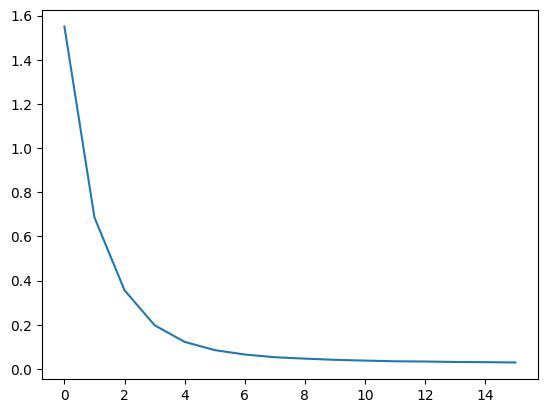

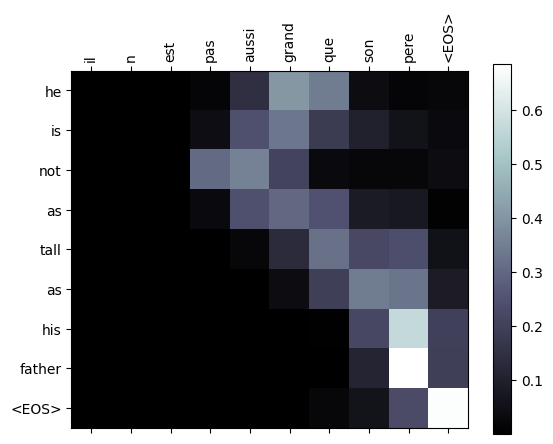

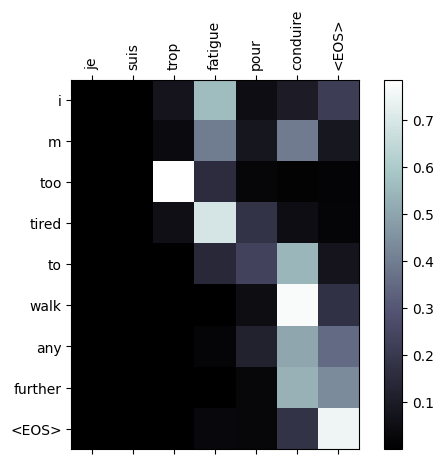

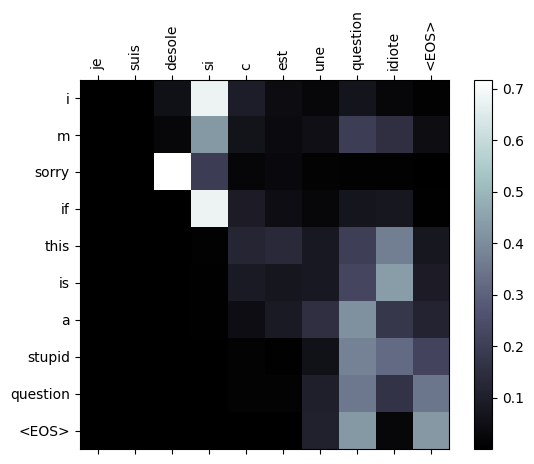

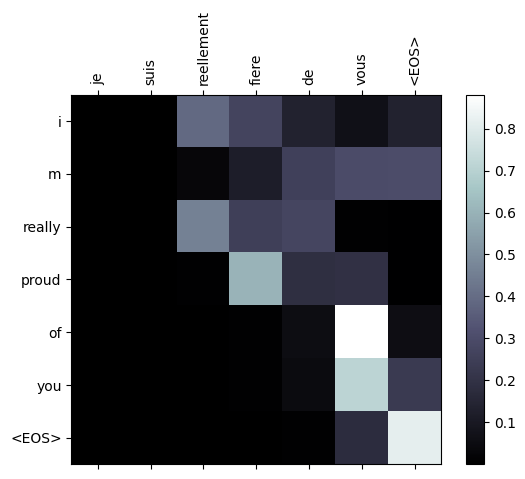

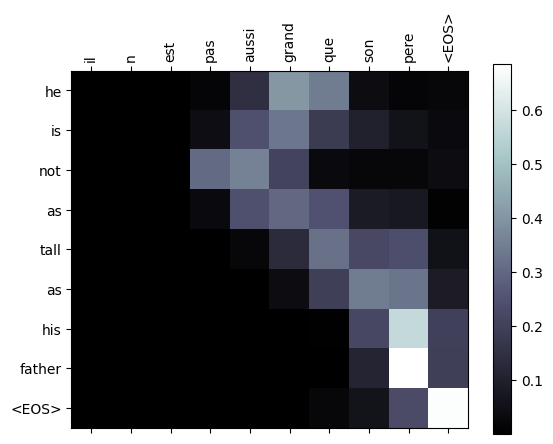

input = je suis trop fatigue pour conduire
output = i m too tired to walk any further <EOS>


/tmp/ipython-input-532627700.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipython-input-532627700.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


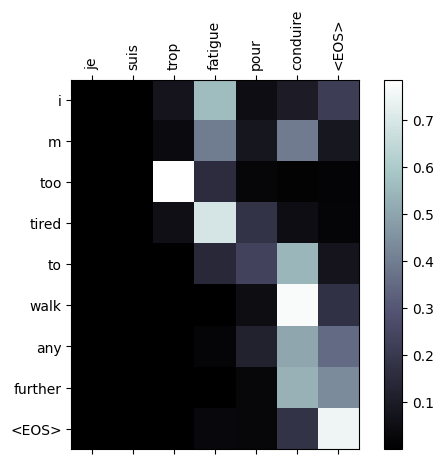

input = je suis desole si c est une question idiote
output = i m sorry if this is a stupid question <EOS>


/tmp/ipython-input-532627700.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipython-input-532627700.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


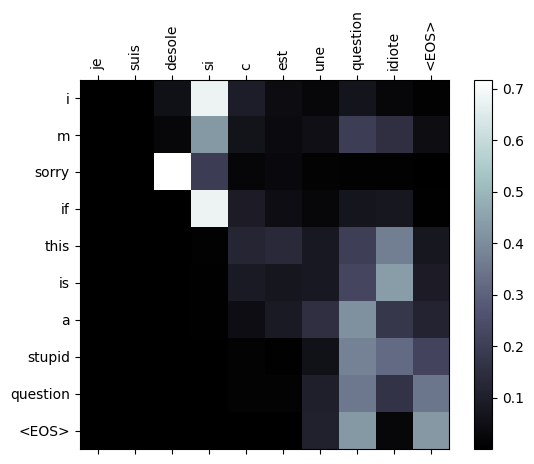

input = je suis reellement fiere de vous
output = i m really proud of you <EOS>


/tmp/ipython-input-532627700.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipython-input-532627700.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


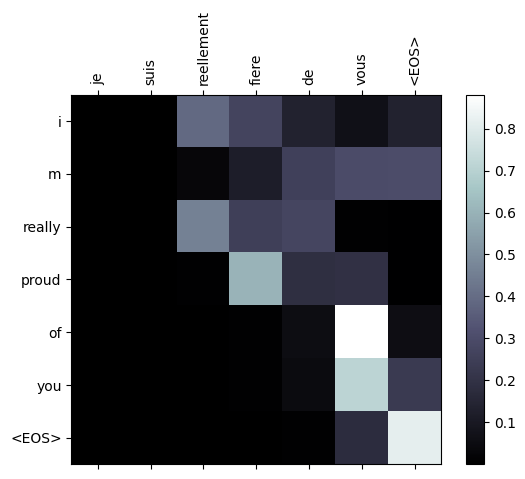

In [24]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone') #그림을 그리려면 gpu->cpu & tensor->numpy로 변환해야함. cmap: 0.0~1.0 사이 (bone:검정 흰색 계열) 색 구분
    fig.colorbar(cax) #그림 옆에 색이 무엇을 의미하는지 바 추가

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') +
                       ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1)) #한칸에 하나씩 표시
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :]) #attentions: [batch, MAX_LENGTH, MAX_LENGTH] -> [output word size, MAX_LENGTH] 사이즈 변경


evaluateAndShowAttention('il n est pas aussi grand que son pere')

evaluateAndShowAttention('je suis trop fatigue pour conduire')

evaluateAndShowAttention('je suis desole si c est une question idiote')

evaluateAndShowAttention('je suis reellement fiere de vous')

Exercises
=========

-   Try with a different dataset
    -   Another language pair
    -   Human → Machine (e.g. IOT commands)
    -   Chat → Response
    -   Question → Answer
-   Replace the embeddings with pretrained word embeddings such as
    `word2vec` or `GloVe`
-   Try with more layers, more hidden units, and more sentences. Compare
    the training time and results.
-   If you use a translation file where pairs have two of the same
    phrase (`I am test \t I am test`), you can use this as an
    autoencoder. Try this:
    -   Train as an autoencoder
    -   Save only the Encoder network
    -   Train a new Decoder for translation from there
